# Intro

This is what I've learnt in the Kaggle competition <a href = "https://www.kaggle.com/competitions/playground-series-s5e5">Predict Calorie Expenditure</a>

Most of what is present here is taken from (learnt from) <a href = "https://www.kaggle.com/code/solomonajaero/s05-e05-eda-catboost">Solomon Ajaero's Notebook</a>

This is also my first time working with CatBoost, so I will be presenting my views on every major part of the code(and also at segments which I've used for the first time.) in an attempt to try and explain what is actually going on, at least as best I can understand it.

Thank You for reading this.

#### Import modules

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_log_error, make_scorer
# Using make_scorer for the first time

from sklearn.model_selection import KFold, train_test_split, cross_val_score
from catboost import CatBoostRegressor, Pool
from xgboost import XGBRegressor
import lightgbm as lgb
import optuna  #First use
import warnings
warnings.filterwarnings('ignore',category=FutureWarning)

c:\Users\heroh\miniconda3\envs\Main\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


#### Load Data

In [2]:
train = pd.read_csv("../Calorie_data/train.csv")
test = pd.read_csv("../Calorie_data/test.csv")

#### Missing Values Analysis 

In [3]:
# Function to display missing values and data types
def check_missing_and_dtypes(df, name="Dataset"):
    print(f"\n{name} Info:")
    print("-" * 50)
    nulls = df.isnull().sum()
    dtypes = df.dtypes
    summary = pd.DataFrame({
        "Data Type": dtypes,
        "Missing Values": nulls,
        "Missing (%)": (nulls / len(df)) * 100
    })
    print(summary)
    return summary


train_info = check_missing_and_dtypes(train, "Train Set")
test_info = check_missing_and_dtypes(test, "Test Set")


Train Set Info:
--------------------------------------------------
           Data Type  Missing Values  Missing (%)
id             int64               0          0.0
Sex           object               0          0.0
Age            int64               0          0.0
Height       float64               0          0.0
Weight       float64               0          0.0
Duration     float64               0          0.0
Heart_Rate   float64               0          0.0
Body_Temp    float64               0          0.0
Calories     float64               0          0.0

Test Set Info:
--------------------------------------------------
           Data Type  Missing Values  Missing (%)
id             int64               0          0.0
Sex           object               0          0.0
Age            int64               0          0.0
Height       float64               0          0.0
Weight       float64               0          0.0
Duration     float64               0          0.0
Heart_Rate   fl

#### EDA

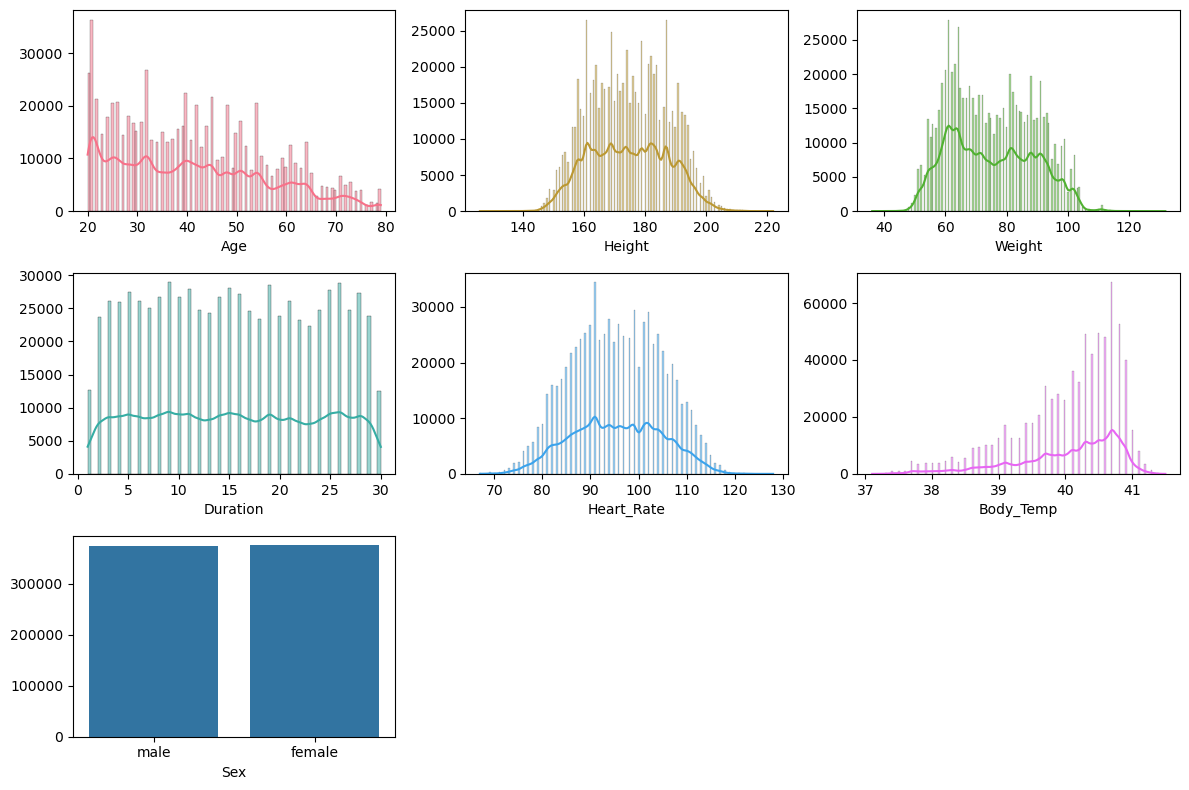

In [4]:
#univariate distribution of the features.

col = ["Age", "Height", "Weight", "Duration", "Heart_Rate", "Body_Temp"]
colors = sns.color_palette("husl", len(col))

fig, axes = plt.subplots(3, 3, figsize=(12, 8))  
axes = axes.flatten()


for i in range(len(col)):
    sns.histplot(train[col[i]], kde=True, ax=axes[i], color=colors[i])
    axes[i].set_ylabel("")


sns.countplot(x='Sex', data=train, ax=axes[len(col)])
axes[len(col)].set_ylabel("")


for j in range(len(col) + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

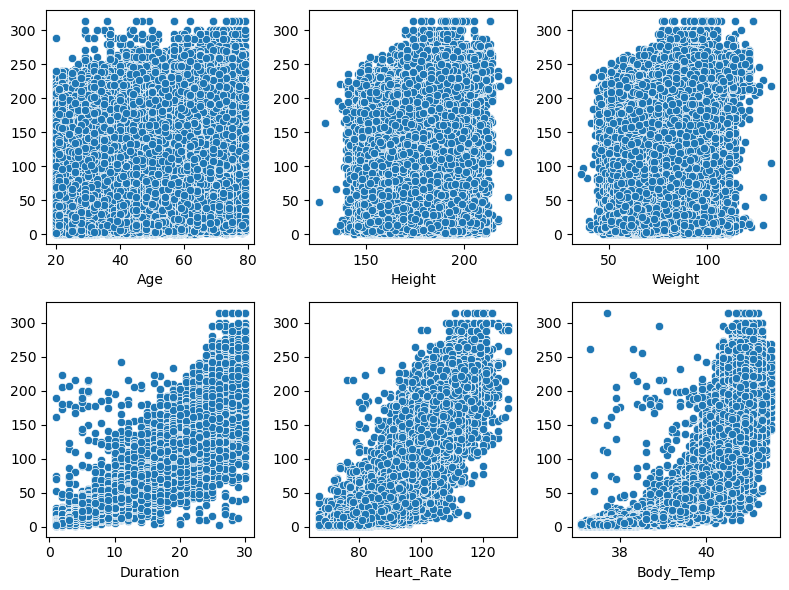

In [5]:
#relationship between numeric features and calories burned
col = ["Age", "Height", "Weight", "Duration", "Heart_Rate", "Body_Temp"]


fig, axes = plt.subplots(2,3, figsize = (8, 6) )

axes = axes.flatten()

for i in range(len(axes)):
    if i < len(col):
        sns.scatterplot(x = col[i], y = 'Calories', data = train, ax = axes[i])
        axes[i].set_ylabel("")
    else:
        fig.delaxes(axes[i])
plt.tight_layout()
plt.show()

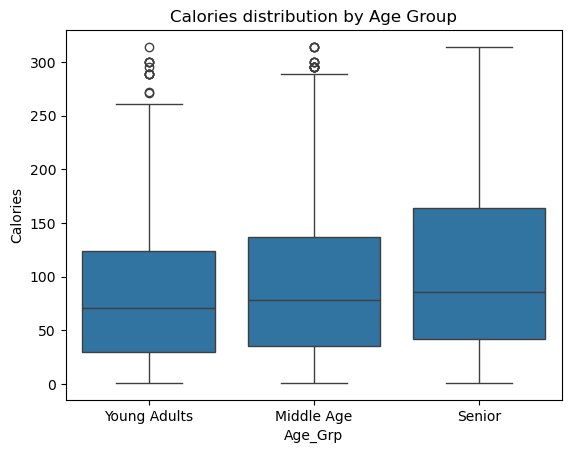

In [6]:
"""
From the charts above, there is no apparent linear relationship between age, height, or weight and calories burned. 
However, a linear relationship appears to exist between calories and duration, heart rate, and body temperature.   

"""
#create categorical grouping for age
bins = [20, 35, 55, 80]
labels = ['Young Adults', 'Middle Age', 'Senior']

train['Age_Grp'] = pd.cut(train['Age'], bins = bins, labels = labels, right = True, include_lowest = True)
#test['Age_Grp'] = pd.cut(test['Age'], bins = bins, labels = labels, right = True, include_lowest = True)


#bivariate relationship between age grp and calories
sns.boxplot(x='Age_Grp', y='Calories', data=train)
plt.title('Calories distribution by Age Group')
plt.show()

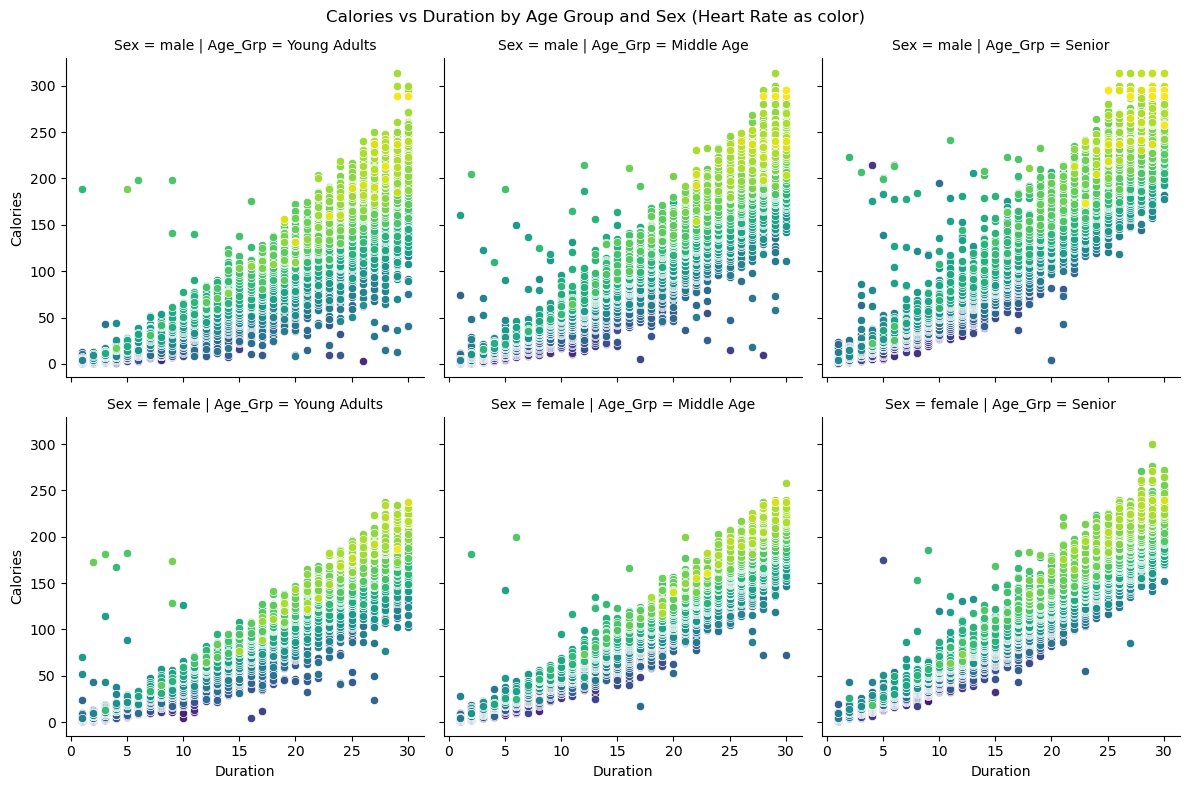

In [7]:
""""
From the boxplot, the amount of calories burned tends to increase from young adults to seniors. 
Next, let's explore how calorie expenditure varies across sex and workout duration.
"""
g = sns.FacetGrid(train, col="Age_Grp", row="Sex", hue="Heart_Rate", palette="viridis", height=4)
g.map(sns.scatterplot, "Duration", "Calories")

plt.subplots_adjust(top=0.9)
g.fig.suptitle('Calories vs Duration by Age Group and Sex (Heart Rate as color)')

plt.tight_layout()
plt.show()

#### Feature Engineering

In [ ]:
# Encode 'Sex' to numeric values
train['Sex'] = train['Sex'].map({'male': 1, 'female': 0}).astype(int)
test['Sex'] = test['Sex'].map({'male': 1, 'female': 0}).astype(int)

In [ ]:
def feature_engineering(df):
    # Intensity index
    df['Intensity_Index'] = df['Heart_Rate'] / df['Duration']

    # Log transformations 
    df['Age'] = np.log1p(df['Age'])
    df['Body_Temp'] = np.log1p(df['Body_Temp'])

    # Basal Metabolic Rate
    df['BMR'] = (
        10 * df['Weight'] + 
        6.25 * df['Height'] - 
        5 * df['Age'] + 
        np.where(df['Sex'] == 1, 5, -161)
    )

    # Core interactions
    df['HR_Temp_Interaction'] = df['Heart_Rate'] * df['Body_Temp']
    df['HR_Duration_Interaction'] = df['Heart_Rate'] * df['Duration']
    df['Metabolic_Load'] = df['Heart_Rate'] * df['Body_Temp'] * df['Duration']
    df['Age_Duration'] = df['Age'] * df['Duration']
    df['Age_Body_Temp'] = df['Age'] * df['Body_Temp']
    df['Duration_Body_Temp'] = df['Duration'] * df['Body_Temp']
    df['Age_Duration_Temp'] = df['Age'] * df['Duration'] * df['Body_Temp']

    # Height & Weight interactions 
    df['Height_Weight'] = df['Height'] * df['Weight']
    df['Height_Duration'] = df['Height'] * df['Duration']
    df['Weight_Duration'] = df['Weight'] * df['Duration']
    df['Weight_HeartRate'] = df['Weight'] * df['Heart_Rate']
    df['Weight_BodyTemp'] = df['Weight'] * df['Body_Temp']
    df['Height_Temp_Interaction'] = df['Height'] * df['Body_Temp']
    df['Weight_Duration_Temp'] = df['Weight'] * df['Duration'] * df['Body_Temp']
    df['Height_Duration_Temp'] = df['Height'] * df['Duration'] * df['Body_Temp']
    df['Weight_HR_Duration'] = df['Weight'] * df['Heart_Rate'] * df['Duration']
    df['Height_HR_Duration'] = df['Height'] * df['Heart_Rate'] * df['Duration']

    # Advanced exertion interactions
    df['Weight_Intensity_Index'] = df['Weight'] * df['Intensity_Index']
    df['Height_Intensity_Index'] = df['Height'] * df['Intensity_Index']
    df['Weight_HR_Temp_Interaction'] = df['Weight'] * df['HR_Temp_Interaction']
    df['Height_HR_Temp_Interaction'] = df['Height'] * df['HR_Temp_Interaction']

    # Ratio and Normalized Features
    df['HR_per_kg'] = df['Heart_Rate'] / df['Weight']
    df['Duration_per_kg'] = df['Duration'] / df['Weight']
    df['Temp_per_kg'] = df['Body_Temp'] / df['Weight']
    df['HR_per_cm'] = df['Heart_Rate'] / df['Height']
    df['Duration_per_cm'] = df['Duration'] / df['Height']
    df['BMI'] = df['Weight'] / (df['Height'] / 100) ** 2

    # Energy & exertion approximations
    df['Energy_Exerted'] = df['Weight'] * df['Heart_Rate'] * df['Duration'] / 10000
    df['Weighted_Intensity'] = df['Intensity_Index'] * df['Weight']

    # BMR interactions
    df['BMR_HR'] = df['BMR'] * df['Heart_Rate']
    df['BMR_Duration'] = df['BMR'] * df['Duration']
    df['BMR_Temp'] = df['BMR'] * df['Body_Temp']
    df['BMR_Intensity'] = df['BMR'] * df['Intensity_Index']

    # Polynomial and log features
    df['HR_Squared'] = df['Heart_Rate'] ** 2
    df['Duration_Squared'] = df['Duration'] ** 2
    df['Temp_Squared'] = df['Body_Temp'] ** 2
    df['Log_HR'] = np.log1p(df['Heart_Rate'])

    # Sex-based interaction features
    df['Sex_male_HR'] = df['Heart_Rate'] * (df['Sex'] == 1)
    df['Sex_female_HR'] = df['Heart_Rate'] * (df['Sex'] == 0)

    df['Sex_male_Weight'] = df['Weight'] * (df['Sex'] == 1)
    df['Sex_female_Weight'] = df['Weight'] * (df['Sex'] == 0)


    # Log transform target (Calories) 
    if 'Calories' in df.columns:
        df['Calories'] = np.log1p(df['Calories'])

    return df


# Apply to both datasets
train = feature_engineering(train)
test = feature_engineering(test)

#### Model Creation/Training & Tuning Hyperparameters

In [ ]:
test_df = test.drop(['id'], axis = 1)

x = train.drop(['Calories', 'id', 'Age_Grp'], axis = 1)
y = train['Calories']

In [ ]:
#split x and y into training and validation sets
x_train, x_val, y_train, y_val = train_test_split(x, y, test_size = 0.2, random_state = 4)

In [ ]:
## Define custom RMSLE metric
def rmsle(y_val_log, y_pred_log):
    # Reverse log1p transformation
    y_val = np.expm1(y_val_log)
    y_pred = np.expm1(y_pred_log)
    preds = np.maximum(0, y_pred)
    return np.sqrt(mean_squared_log_error(y_val, preds))

# Define the Optuna objective function
def objective(trial):
    params = {
        'iterations': trial.suggest_int('iterations', 2000, 7000),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'depth': trial.suggest_int('depth', 6, 16),  
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1, 100, log = True),
        'grow_policy': 'SymmetricTree',
        'loss_function': 'RMSE',
        'eval_metric': 'RMSE',
        'random_seed': 34,
        'early_stopping_rounds': 100,
        'use_best_model': True,
        'verbose': 0
    }


    train_pool = Pool(data=x_train, label=y_train)
    valid_pool = Pool(data=x_val, label=y_val)


    model = CatBoostRegressor(**params)
    model.fit(train_pool, eval_set=valid_pool)


    preds = model.predict(valid_pool)
    score = rmsle(y_val, preds)
    return score

In [ ]:
# Train CatBoost with the best parameters obtained from the Optuna hyperparameter tuning above.
cat_model = CatBoostRegressor(
    iterations = 4788,
    learning_rate = 0.021048601257810478,
    l2_leaf_reg = 2.211703712973945,
    grow_policy = 'SymmetricTree',
    loss_function = 'RMSE', 
    eval_metric='RMSE',
    random_seed = 34,
    
    depth = 14,
    verbose = 0
)

cat_model.fit(x_train, y_train,
             eval_set = (x_val, y_val),
             use_best_model = True)

In [ ]:
cat_pred = cat_model.predict(x_val)

cat_pred = np.expm1(cat_pred)
y_val = np.expm1(y_val)

rmsle = np.sqrt(mean_squared_log_error(cat_pred, y_val))

rmsle

In [ ]:
# Extract and Plot RMSE per Iteration

evals_result = cat_model.evals_result_

# Plot RMSE for training and validation
plt.figure(figsize=(10, 6))
plt.plot(evals_result['learn']['RMSE'], label='Train RMSE')
plt.plot(evals_result['validation']['RMSE'], label='Validation RMSE')
plt.xlabel('Iterations')
plt.ylabel('RMSE')
plt.title('CatBoost Learning Curve')
plt.legend()
plt.grid(True)
plt.show()